In [2]:
import pathlib

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from tqdm.notebook import tqdm

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [5]:
# check if cuda is available
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.empty_cache()
else:
    device = "cpu"

# Get the dataset

In [7]:
import kagglehub

In [8]:
path = kagglehub.dataset_download("sanikamal/horses-or-humans-dataset")
path += "/horse-or-human"

In [9]:
# convert to pytorch dataloader

In [10]:
# first pyTorch dataset
from torch.utils.data import Dataset
from torchvision.io import decode_image

class HvsHDataset(Dataset):
    def __init__(self, path, train=True):
        if train:
            path += "/train/"
        else:
            path += "/validation/"
        self.img_files = []
        for ci, c in enumerate(["horses", "humans"]):
            for f in pathlib.Path(path+c).iterdir():
                self.img_files.append((str(f), torch.tensor(ci)))
                print(str(f), ci)

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path, y = self.img_files[idx]
        image = decode_image(img_path)
        image = image[:3,:,:]  # skip alpha channel
        return image, y

/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse46-4.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse40-1.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse06-2.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse07-7.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse48-3.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse32-5.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse08-2.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse50-7.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse23-3.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse11-8.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse48-8.png 0
/kaggle/input/horses-or-humans-dataset/horse-or-human/train/horses/horse18-7.png 0
/kag

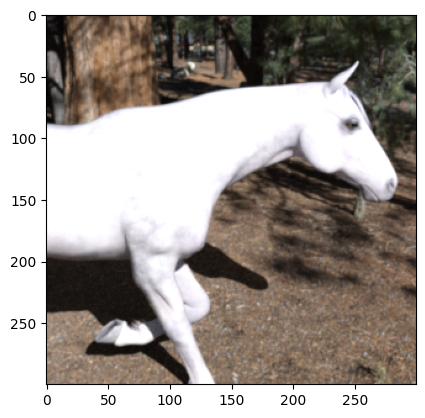

In [14]:
d_train = HvsHDataset(path, True)
d_test = HvsHDataset(path, False)

x, y = d_train[0]
print(y)
plt.imshow(x.numpy().transpose((1,2,0)))

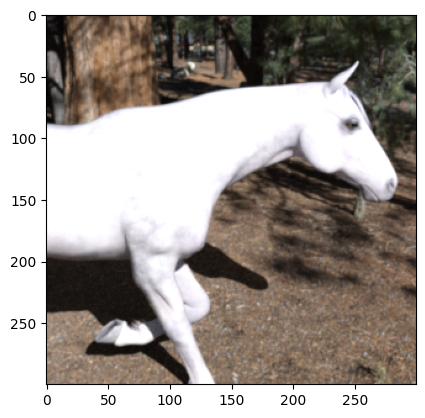

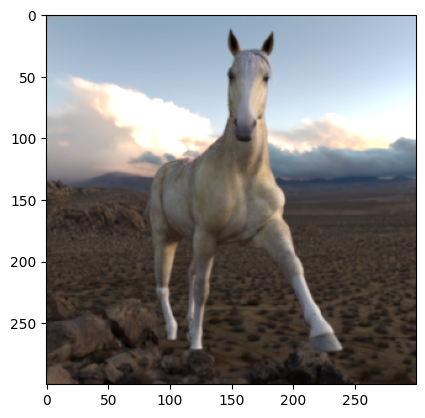

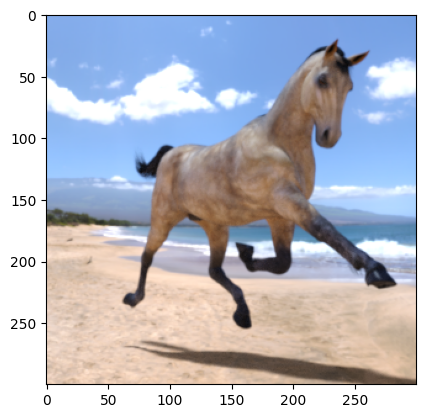

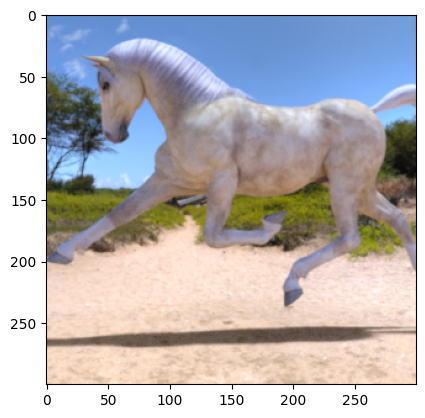

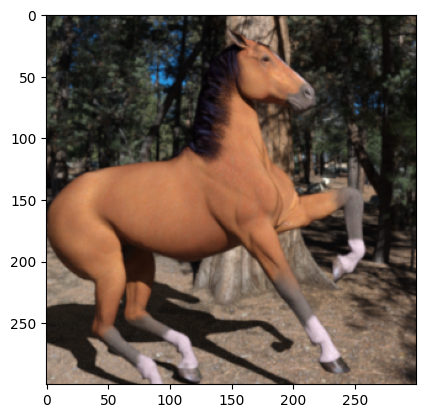

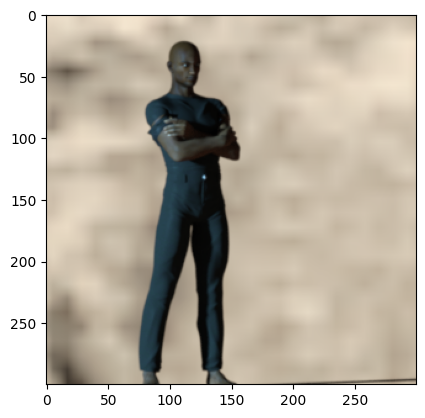

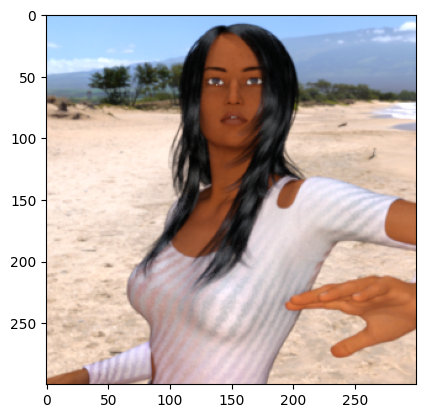

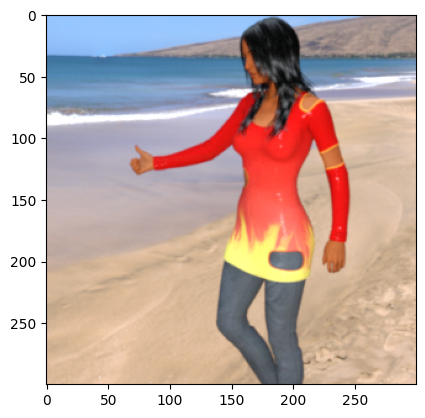

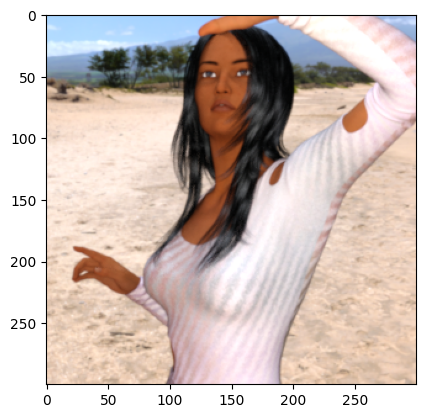

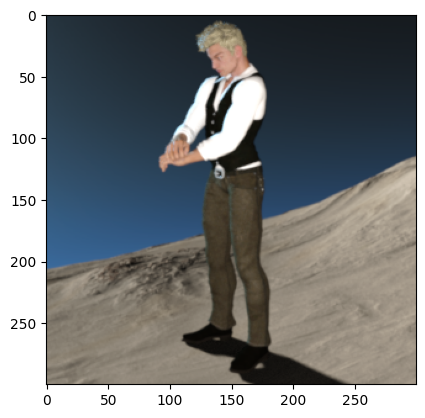

In [15]:
# show 5 horses and 5 humans
for i in range(5):
    plt.figure()
    plt.imshow(d_train[i][0].numpy().transpose((1,2,0)))
for i in range(500, 510)[:5]:
    plt.figure()
    plt.imshow(d_train[i][0].numpy().transpose((1,2,0)))

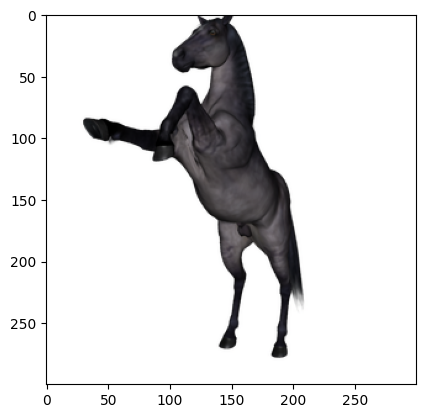

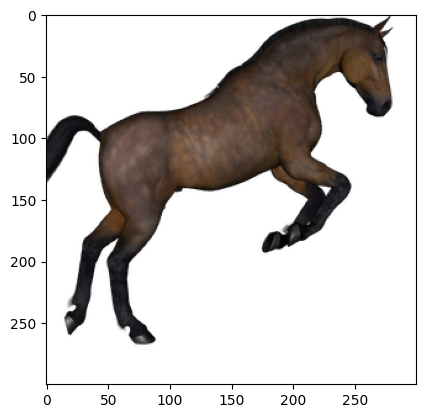

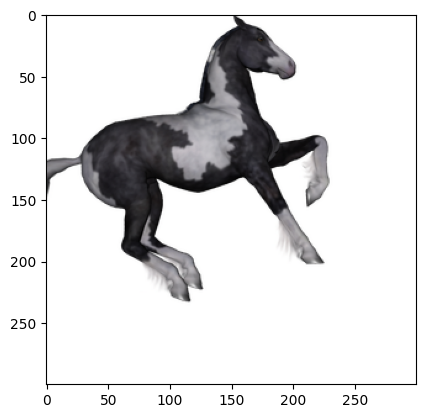

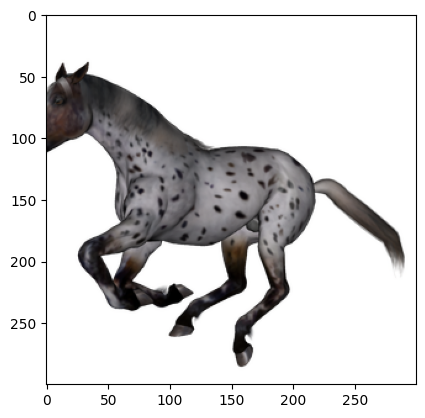

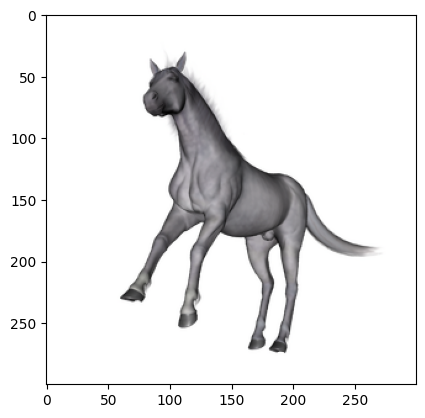

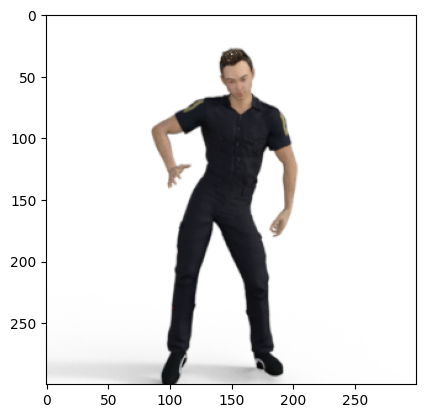

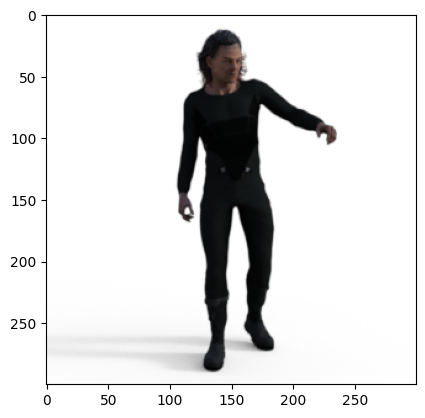

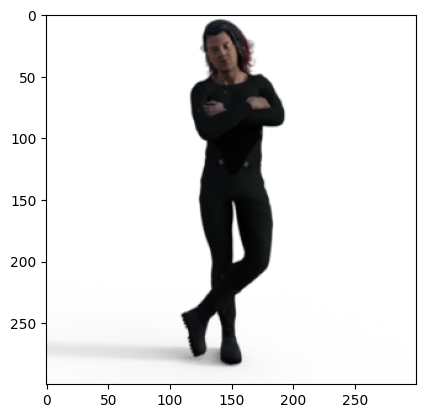

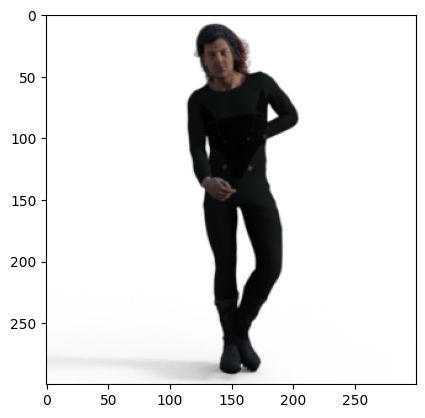

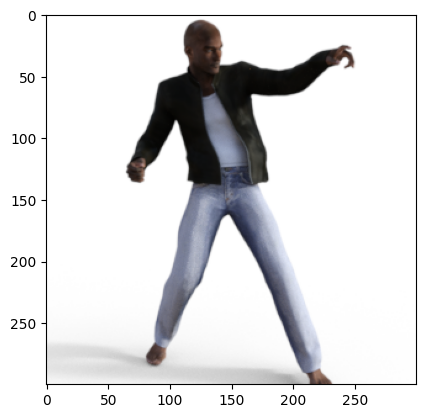

In [17]:
# same for test set
for i in range(5):
    plt.figure()
    plt.imshow(d_test[i][0].numpy().transpose((1,2,0)))
for i in range(200, 510)[:5]:
    plt.figure()
    plt.imshow(d_test[i][0].numpy().transpose((1,2,0)))

In [18]:
# automatically shuffle and split into batches using DataLoader
from torch.utils.data import DataLoader
train_dataloader = DataLoader(d_train, batch_size=32, shuffle=True)
test_dataloader = DataLoader(d_test, batch_size=32, shuffle=True)

# Load the Inception V3 network

In [19]:
import torchvision
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 89.5MB/s]


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [20]:
# get preprocessing function
vw = torchvision.models.get_model_weights("inception_v3")
# wstepne przetworzenie obrazu
preproc = vw.DEFAULT.transforms()

### just test original network's predictions

In [24]:
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

--2025-04-10 09:18:40--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt.1’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2025-04-10 09:18:40 (117 MB/s) - ‘imagenet_classes.txt.1’ saved [10472/10472]



In [22]:
with open("imagenet_classes.txt") as f:
    imagenet_classes = [l.strip() for l in f]
def decode_predictions(preds, top=5):
    top_preds = np.argsort(preds[0])[-top:]
    for i in reversed(top_preds):
        print(f"{imagenet_classes[i]}: {preds[0, i]:.2}", end=" ")
    print()

In [25]:
x, y = next(iter(train_dataloader))
x = x.to(device)
net.eval()
with torch.no_grad():
    pred = F.softmax(net(preproc(x)), dim=-1).cpu()
    for i in range(20):
        #plt.imshow(x[i].cpu().numpy().transpose((1,2,0)))
        print(y[i].item(), end="  ")
        decode_predictions(pred[i:i+1])
print("\n\n")
# sorrel is OK!  but dogs often come out
# for humans: clothes come up

# need to adapt the network

1  miniskirt: 0.39 maillot: 0.17 maillot: 0.075 jean: 0.028 brassiere: 0.026 
1  sandbar: 0.95 seashore: 0.024 jean: 0.0013 lakeside: 0.001 swimming trunks: 0.00088 
1  sandbar: 0.84 swimming trunks: 0.024 seashore: 0.0086 snorkel: 0.0074 cowboy boot: 0.0048 
1  crutch: 0.16 ski: 0.093 maypole: 0.068 torch: 0.049 tripod: 0.035 
0  Great Dane: 0.1 whippet: 0.1 Saluki: 0.052 Ibizan hound: 0.019 sea lion: 0.013 
1  bolo tie: 0.68 velvet: 0.14 sweatshirt: 0.036 buckle: 0.028 cloak: 0.0069 
1  maillot: 0.11 ski: 0.084 comic book: 0.029 bathing cap: 0.024 killer whale: 0.024 
1  sweatshirt: 0.27 jersey: 0.06 maraca: 0.035 crutch: 0.02 velvet: 0.019 
0  sorrel: 0.8 hartebeest: 0.015 vizsla: 0.0052 Rhodesian ridgeback: 0.0038 redbone: 0.0024 
0  sorrel: 0.17 horse cart: 0.074 hartebeest: 0.029 Mexican hairless: 0.021 bighorn: 0.012 
0  sorrel: 0.45 hartebeest: 0.082 vizsla: 0.03 boxer: 0.025 redbone: 0.02 
1  sandbar: 0.34 sweatshirt: 0.11 cowboy boot: 0.052 lakeside: 0.037 swimming trunks: 0.

### Helper functions

In [26]:
# function to evaluate accuracy
def eval_net(net, d):
    net.eval()
    with torch.no_grad():
        acc_sum = 0
        n = 0
        for x, y in tqdm(d):
            pred = net(preproc(x.to(device)))
            predicted = (1*(pred > 0.5)).cpu()
            acc_sum += (predicted==y.unsqueeze(-1)).sum().item()
            n += x.shape[0]
    return acc_sum/n

In [28]:
# training loop
import torch.optim as optim

def fit(net, train=train_dataloader, valid=test_dataloader, epochs=5, lr=None):
    if torch.cuda.is_available():
        device = "cuda"
        torch.cuda.empty_cache()
    else:
        device = "cpu"
    net = net.to(device)

    if lr is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=lr)
    epochs = epochs
    # single output: use a different loss:
    # binary cross entropy
    loss = torch.nn.BCEWithLogitsLoss()  # includes sigmoid activation
    for e in range(epochs):
        #net.train() # don't do it for transfer learning!!!
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(preproc(X))
            try:
                # in training mode inception returns a tuple
                pred = pred.logits
            except:
                pass
            l = loss(pred, y.unsqueeze(-1).float())
            l.backward()
            optimizer.step()

# Let's do actual transfer learning

In [29]:
print(net)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [30]:
# note the final fc layer
print(net.fc)
print(net.fc.in_features)

Linear(in_features=2048, out_features=1000, bias=True)
2048


In [31]:
# need to replace the top layer with our own layer
net.fc = nn.Linear(net.fc.in_features, 1).to(device)
# remember: copy the new layer to GPU!

In [32]:
# just accuracy before training
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 0.51171875


In [34]:
# train ONLY the top layer (tricky part)
net.eval() # przełaczenie na ewaluacje beedzie wplyweac tylko na dropouty - wyłacza dropout
net.requires_grad_(False)  # .eval() is not enough
net.fc.requires_grad_(True)
net.fc.train()

Linear(in_features=2048, out_features=1, bias=True)

In [35]:
fit(net, epochs=5)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

In [37]:
# accuracy after transfer
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 1.0


In [ ]:
# nice!  this is on a test set without backgrounds

# Adding a more complex classifier

In [ ]:
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.to(device)
net.fc = nn.Sequential(nn.Linear(net.fc.in_features, 64),
                        nn.ReLU(),
                        nn.Dropout(0.25),
                        nn.Linear(64, 1)).to(device)
net.eval()
net.requires_grad_(False)  # .eval() is not enough
net.fc.requires_grad_(True)
net.fc.train()

Sequential(
  (0): Linear(in_features=2048, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.25, inplace=False)
  (3): Linear(in_features=64, out_features=1, bias=True)
)

In [39]:
fit(net, epochs=5)
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 1.0


# Now train the full network

In [40]:
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.to(device)
net.fc = nn.Linear(net.fc.in_features, 1).to(device)
net.requires_grad_(True)
_ = net.train()

In [41]:
fit(net, epochs=5)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

In [42]:
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 0.55859375


# Two step training of the full network

In [43]:
# first train ONLY the top layer
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.to(device)
net.fc = nn.Linear(net.fc.in_features, 1).to(device)
net.eval()
net.requires_grad_(False)  # .eval() is not enough
net.fc.requires_grad_(True)
net.fc.train()

Linear(in_features=2048, out_features=1, bias=True)

In [44]:
fit(net, epochs=5)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

In [45]:
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 1.0


In [46]:
# now fine-tune the whole net
net.requires_grad_(True)
_ = net.train()

In [47]:
# use smaller training step
fit(net, epochs=5, lr=1e-4)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

In [49]:
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 0.93359375


# now smaller training step and fewer epochs

In [50]:
# first train ONLY the top layer
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.to(device)
net.fc = nn.Linear(net.fc.in_features, 1).to(device)
net.eval()
net.requires_grad_(False)  # .eval() is not enough
net.fc.requires_grad_(True)
net.fc.train()

Linear(in_features=2048, out_features=1, bias=True)

In [51]:
fit(net, epochs=5)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

In [52]:
net.requires_grad_(True)
_ = net.train()
fit(net, epochs=2, lr=1e-4)

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/33 [00:00<?, ?it/s]

In [53]:
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 0.98046875


# Deeper adaptations of the network

In [54]:
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.to(device)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
# note the avgpool layer: it's insensitive to input shape

In [55]:
# maybe we don't need the last inception module?
net.Mixed_7c

InceptionE(
  (branch1x1): BasicConv2d(
    (conv): Conv2d(2048, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(320, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_1): BasicConv2d(
    (conv): Conv2d(2048, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2a): BasicConv2d(
    (conv): Conv2d(384, 384, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2b): BasicConv2d(
    (conv): Conv2d(384, 384, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3dbl_1): BasicConv2d(
    (conv): Conv2d(2048, 448, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(448, eps=0.001, mo

In [56]:
net.Mixed_7c = nn.Identity()
net.fc = nn.Linear(net.fc.in_features, 1).to(device)
net.eval()
net.requires_grad_(False)  # .eval() is not enough
net.fc.requires_grad_(True)
net.fc.train()

Linear(in_features=2048, out_features=1, bias=True)

In [57]:
fit(net, epochs=1)

  0%|          | 0/33 [00:00<?, ?it/s]

In [58]:
acc_valid = eval_net(net, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 1.0


In [ ]:
# Exercise: try to remove as many modules as possible to get the most efficient network for the task

In [74]:
net_own = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net_own.to(device)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [60]:
net_own.Mixed_7a

InceptionD(
  (branch3x3_1): BasicConv2d(
    (conv): Conv2d(768, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2): BasicConv2d(
    (conv): Conv2d(192, 320, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(320, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch7x7x3_1): BasicConv2d(
    (conv): Conv2d(768, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch7x7x3_2): BasicConv2d(
    (conv): Conv2d(192, 192, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch7x7x3_3): BasicConv2d(
    (conv): Conv2d(192, 192, kernel_size=(7, 1), stride=(1, 1), padding=(3, 0), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, mo

In [61]:
net_own.Mixed_7b

InceptionE(
  (branch1x1): BasicConv2d(
    (conv): Conv2d(1280, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(320, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_1): BasicConv2d(
    (conv): Conv2d(1280, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2a): BasicConv2d(
    (conv): Conv2d(384, 384, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2b): BasicConv2d(
    (conv): Conv2d(384, 384, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3dbl_1): BasicConv2d(
    (conv): Conv2d(1280, 448, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(448, eps=0.001, mo

In [63]:
net_own.Mixed_7c

InceptionE(
  (branch1x1): BasicConv2d(
    (conv): Conv2d(2048, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(320, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_1): BasicConv2d(
    (conv): Conv2d(2048, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2a): BasicConv2d(
    (conv): Conv2d(384, 384, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3_2b): BasicConv2d(
    (conv): Conv2d(384, 384, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0), bias=False)
    (bn): BatchNorm2d(384, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch3x3dbl_1): BasicConv2d(
    (conv): Conv2d(2048, 448, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(448, eps=0.001, mo

In [166]:
net_own = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net_own.to(device)
net_own.Mixed_7a = nn.Sequential(
                          nn.Identity(),
                          # nn.Flatten(),
                          # nn.Linear(32, 768)
                          # nn.Conv2d(768, 32, kernel_size=1),
                          # nn.Linear(32, 768)
                          # nn.Conv2d(1280, 2048, kernel_size=1)
                          # nn.Conv2d(768, 2048, kernel_size=1)
                          # nn.Linear(768*17*17, 2048)
                        ).to(device)
net_own.Mixed_7b = nn.Sequential(
                          nn.Identity(),
                        ).to(device)
net_own.Mixed_7c = nn.Identity()
net_own.fc = nn.Linear(768, 1).to(device)
net_own.eval()
net_own.requires_grad_(False)  # .eval() is not enough
net_own.fc.requires_grad_(True)
net_own.fc.train()

Linear(in_features=768, out_features=1, bias=True)

In [167]:
fit(net_own, epochs=1)

  0%|          | 0/33 [00:00<?, ?it/s]

In [124]:
acc_valid = eval_net(net_own, test_dataloader)
print("Validation accuracy", acc_valid)

  0%|          | 0/8 [00:00<?, ?it/s]

Validation accuracy 0.99609375
